In [1]:
# Use this only for the final pdf generation
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import median_abs_deviation

In [3]:
sc.settings.verbosity = 0             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.15.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [4]:
samples = [
    "PBMC_10x", "PBMC_10x_2", "PBMC_10x_3", "PBMC_indrops", "PBMC_indrops_2", 
    "brain", "brain_2", "eye", "eye_2", "eye_3", "lung_2", "lung_5", "lung_7", "lung_8"
]

In [5]:
adatas = {}
for sample in samples:
    adata_10x = sc.read_10x_mtx(f'../../data/downstream/matrices/{sample}/10x/')
    adata_intergenic = sc.read_10x_mtx(f'../../data/downstream/matrices/intergenic/{sample}/')
    adatas[sample] = sc.concat([adata_10x, adata_intergenic], join = 'outer', axis = 1)

In [6]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [7]:
count_thresholds = { "PBMC_10x" : 800, "PBMC_10x_2" : 1000, "PBMC_10x_3" : 1000,
                   "PBMC_indrops" : 1000, "PBMC_indrops_2" : 3000,
                   "brain" : 700, "brain_2" : 700,
                   "eye" : 800, "eye_2" : 1000, "eye_3" : 1000,
                   "lung_2" : 2000, "lung_5" : 2000, "lung_7" : 2000, "lung_8" : 2000}

In [8]:
for sample in samples:
    adatas[sample].var['mt'] = adatas[sample].var_names.str.startswith('MT')
    adatas[sample].var["ribo"] = adatas[sample].var_names.str.startswith(("RPS", "RPL"))
    adatas[sample].var["hb"] = adatas[sample].var_names.str.contains(("^HB[^(P)]"))
    sc.pp.calculate_qc_metrics(adatas[sample], qc_vars=['mt', 'ribo', 'hb'], percent_top=None, log1p=True, inplace=True)
    cmask = adatas[sample].obs['total_counts'].values>count_thresholds[sample]
    adatas[sample] = adatas[sample][cmask]
    sc.pp.filter_genes(adatas[sample], min_cells=3)
    adatas[sample].obs["outlier"] = (
    is_outlier(adatas[sample], "log1p_total_counts", 5)
    | is_outlier(adatas[sample], "log1p_n_genes_by_counts", 5)
    | is_outlier(adatas[sample], "pct_counts_mt", 3)
    | (adatas[sample].obs["pct_counts_mt"] > 10)
    )
    adatas[sample] = adatas[sample][(~adatas[sample].obs.outlier)].copy()
    sc.external.pp.scrublet(adatas[sample])
    cmask = adatas[sample].obs['predicted_doublet'].values == False
    adatas[sample] = adatas[sample][cmask]

    adatas[sample].layers["celltypist"] = adatas[sample].X

    sc.pp.normalize_total(adatas[sample], target_sum=None)
    sc.pp.log1p(adatas[sample])

    sc.pp.highly_variable_genes(adatas[sample], min_mean=0.0125, max_mean=3, min_disp=0.5)
    adatas[sample] = adatas[sample][:, adatas[sample].var.highly_variable]

PBMC_10x


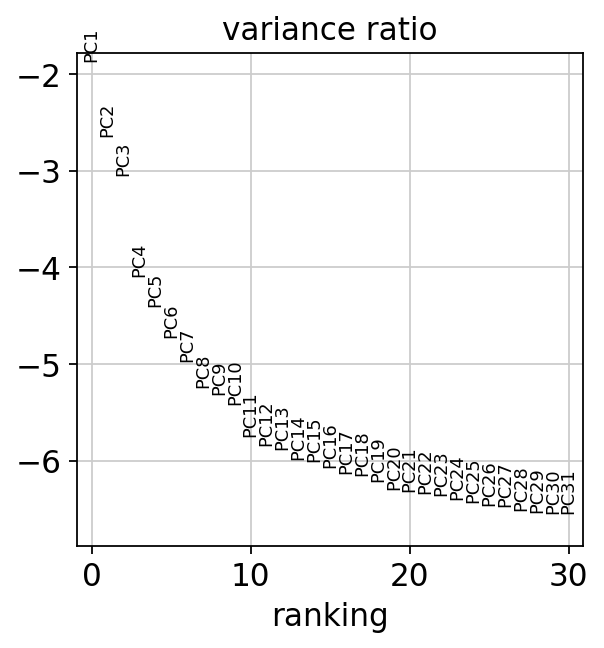

PBMC_10x_2


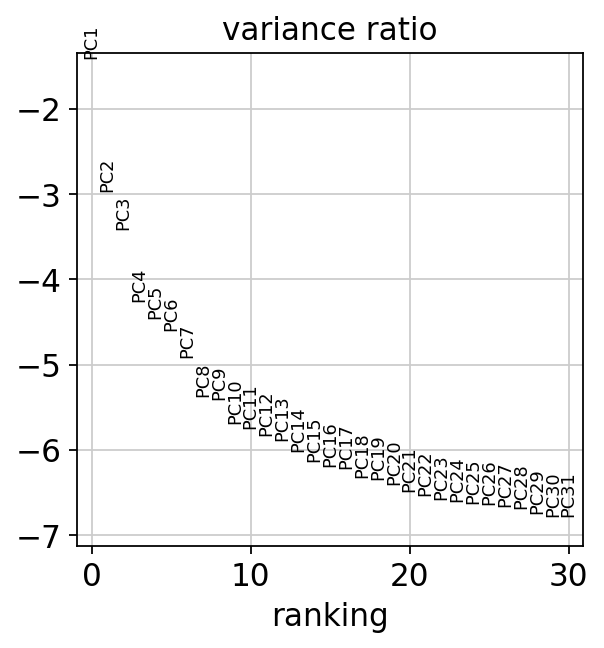

PBMC_10x_3


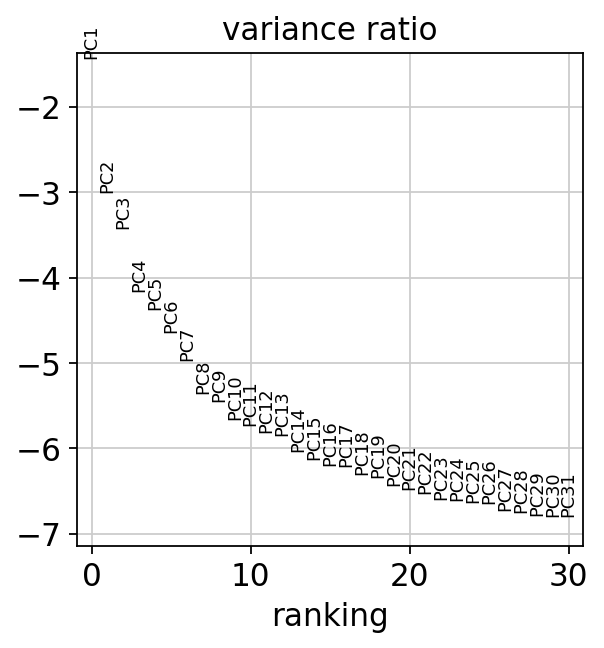

PBMC_indrops


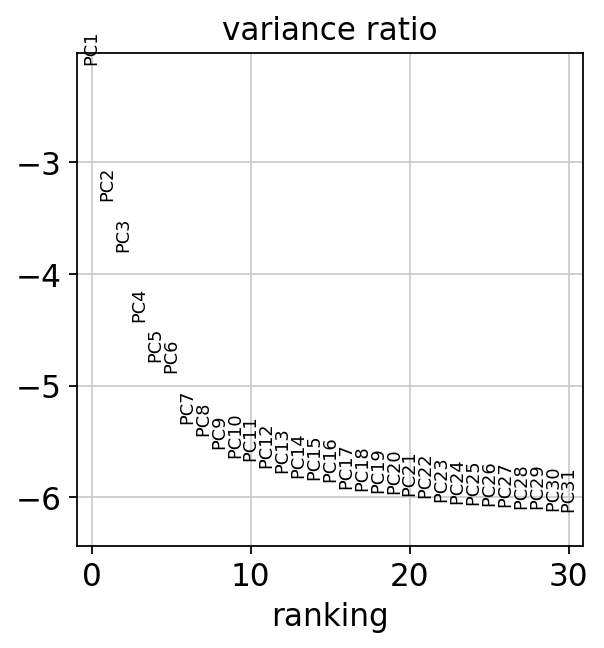

PBMC_indrops_2


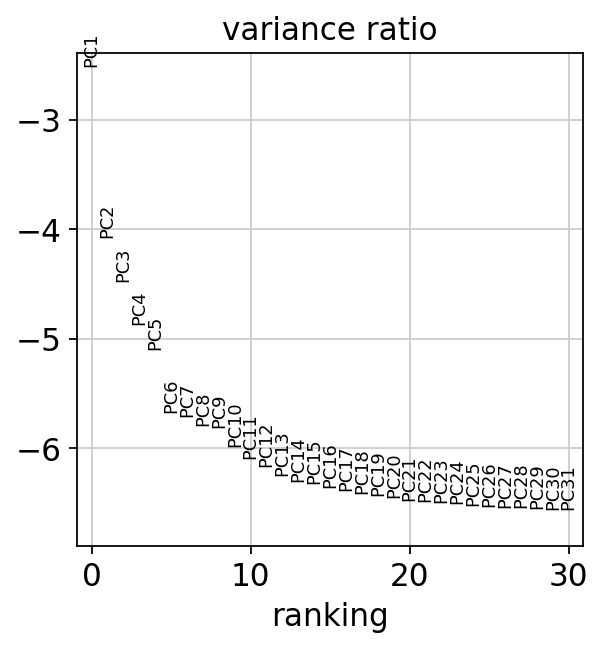

brain


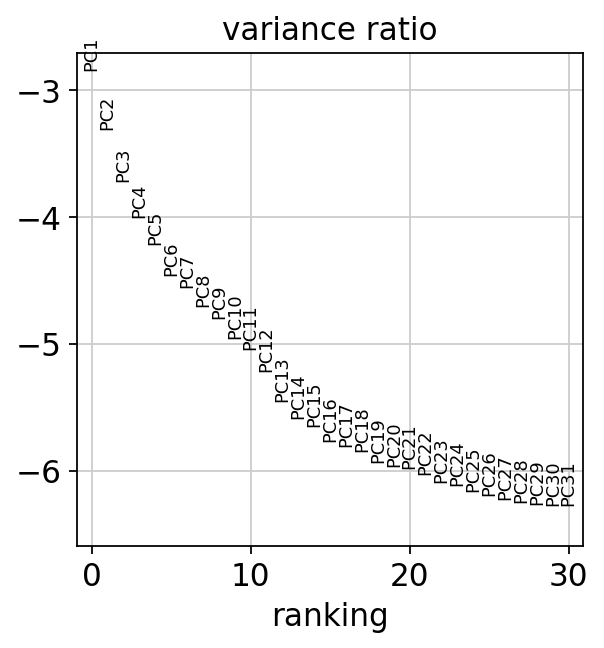

brain_2


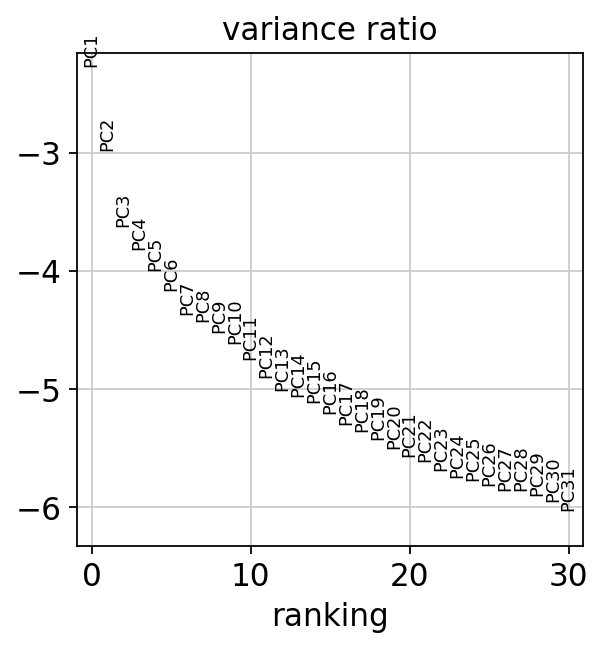

eye


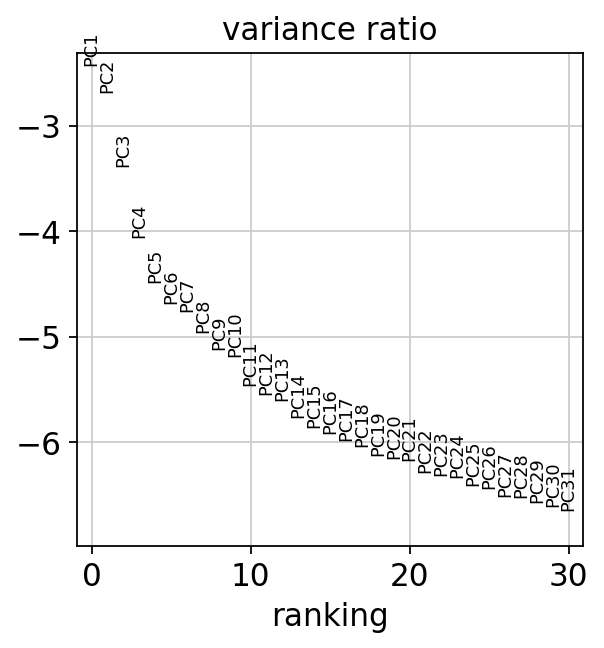

eye_2


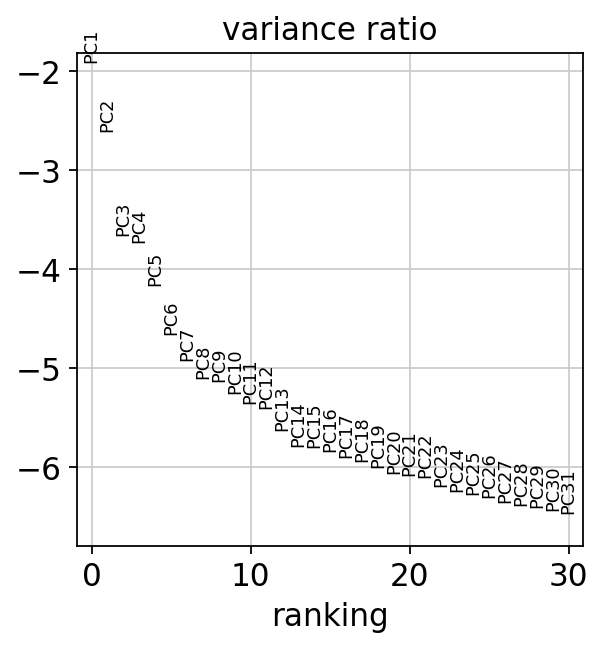

eye_3


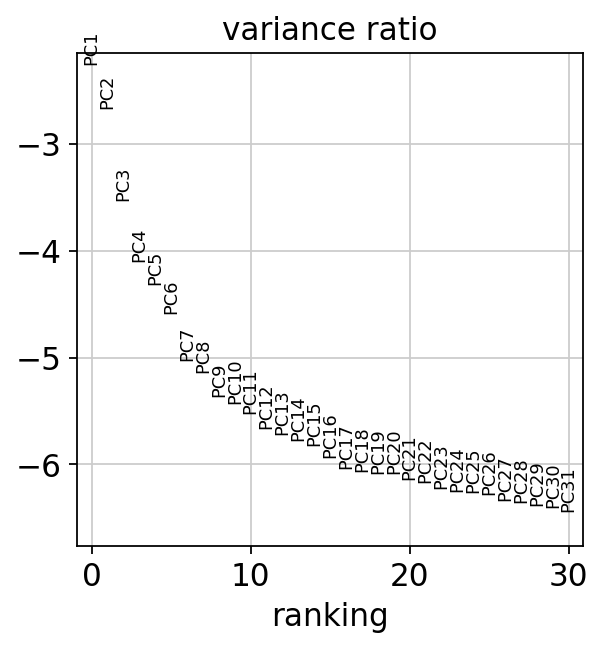

lung_2


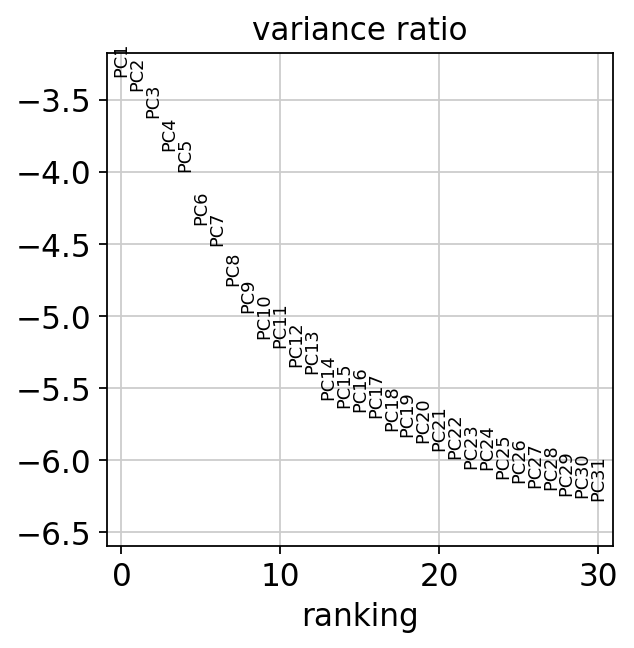

lung_5


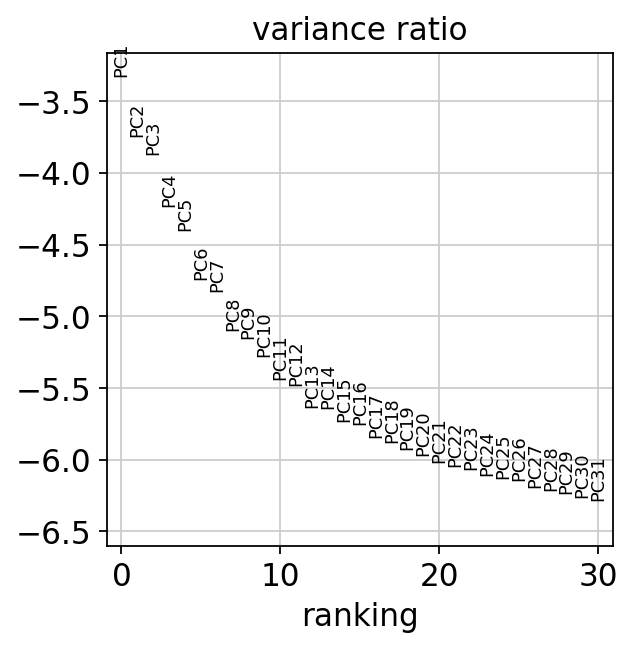

lung_7


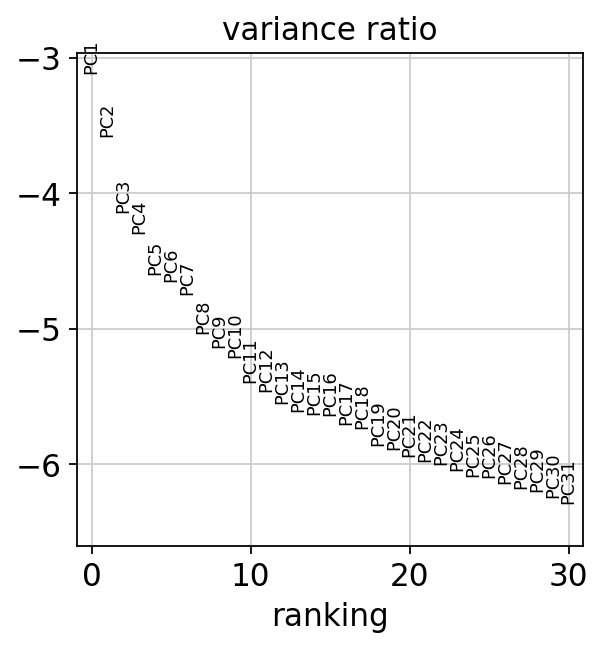

lung_8


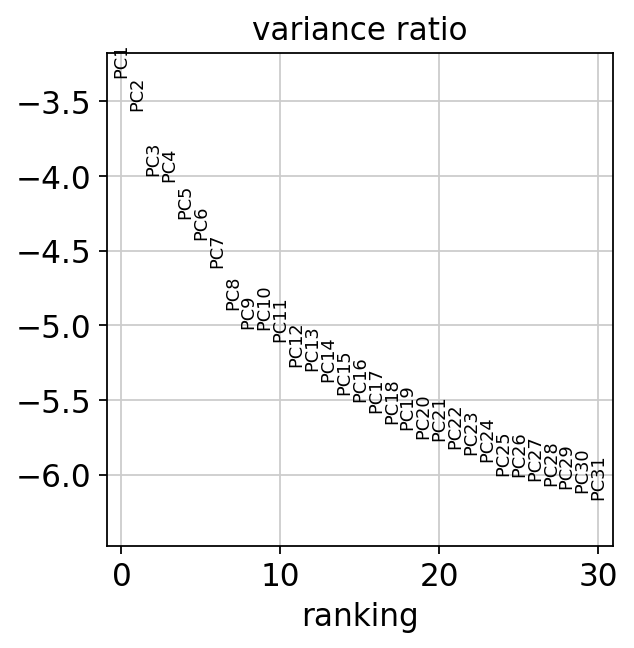

In [9]:
for sample in samples:
    print(sample)
    sc.tl.pca(adatas[sample], svd_solver='arpack')
    sc.pl.pca_variance_ratio(adatas[sample], log=True)

In [10]:
pcas = { "PBMC_10x" : 10, "PBMC_10x_2" : 10, "PBMC_10x_3" : 10,
        "PBMC_indrops" : 8, "PBMC_indrops_2" : 6,
        "brain" : 11, "brain_2" : 11,
        "eye" : 11, "eye_2" : 7, "eye_3" : 7,
        "lung_2" : 10, "lung_5" : 10, "lung_7" : 10, "lung_8" : 10}

In [11]:
for sample in samples:
    sc.pp.neighbors(adatas[sample], n_pcs = pcas[sample])
    sc.tl.umap(adatas[sample])

In [12]:
import celltypist
from celltypist import models

In [13]:
def CellTypist(adata):
    models.download_models(force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"])
    model_low = models.Model.load(model="Immune_All_Low.pkl")
    model_high = models.Model.load(model="Immune_All_High.pkl")
    
    adata_celltypist = adata.copy()
    adata_celltypist.X = adata.layers["celltypist"]
    sc.pp.normalize_total(adata_celltypist, target_sum = 10000)
    sc.pp.log1p(adata_celltypist)
    adata_celltypist.X = adata_celltypist.X.toarray()

    predictions_high = celltypist.annotate(adata_celltypist, model=model_high, majority_voting=True)
    predictions_high_adata = predictions_high.to_adata()
    adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "majority_voting"]
    adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "conf_score"]
    sc.pl.umap(adata,
        color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
        frameon=False,
        sort_order=False,
        wspace=1,
        legend_loc = "on data")
    
    predictions_low = celltypist.annotate(adata_celltypist, model=model_low, majority_voting=True)
    predictions_low_adata = predictions_low.to_adata()
    adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "majority_voting"]
    adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "conf_score"]
    sc.pl.umap(adata,
        color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
        frameon=False,
        sort_order=False,
        wspace=1)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /home/MazutisLab/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 4320 cells and 4161 genes
🔗 Matching reference genes in the model
🧬 1776 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'feature_types' as categorical


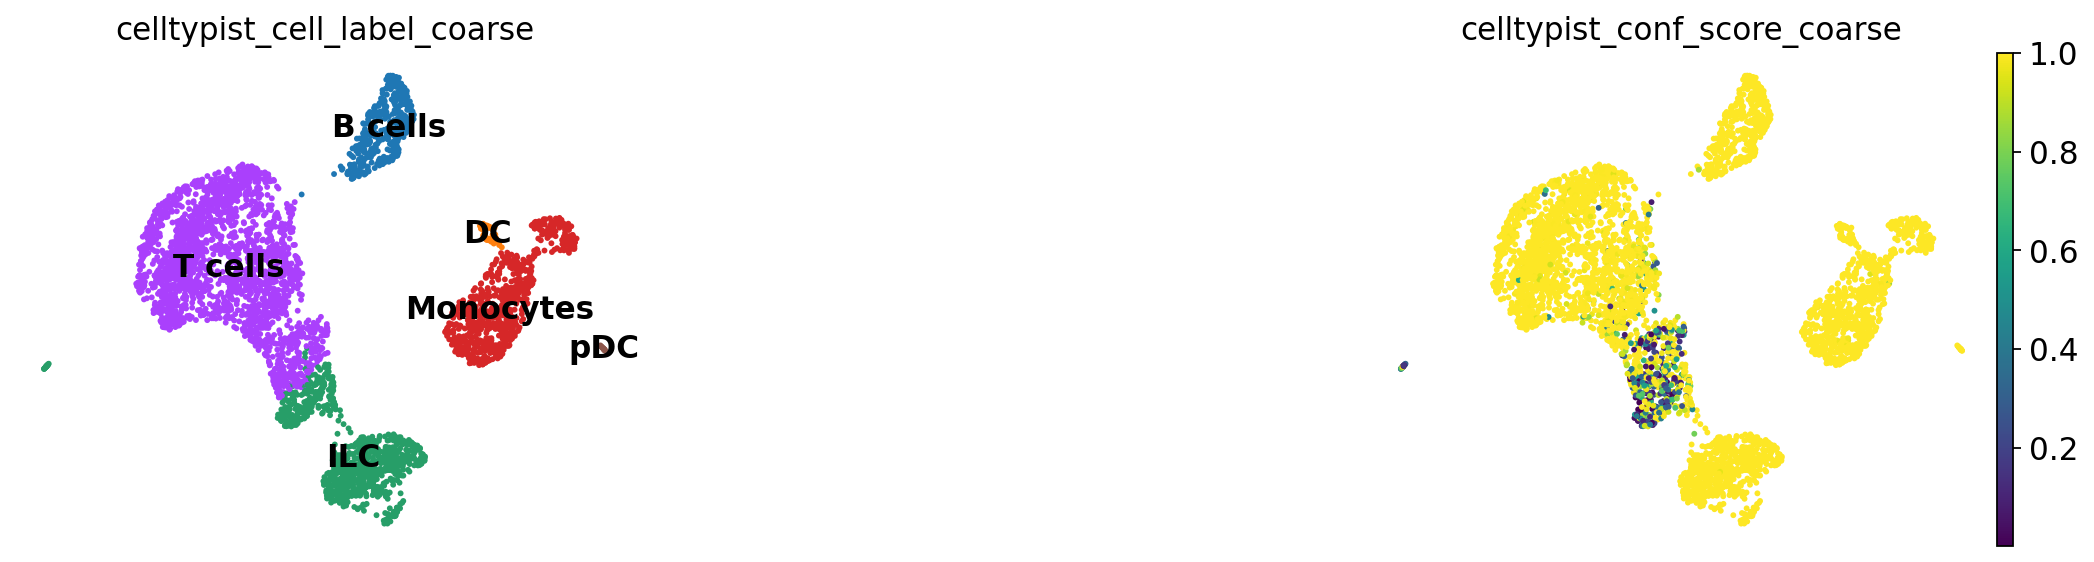

🔬 Input data has 4320 cells and 4161 genes
🔗 Matching reference genes in the model
🧬 1776 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


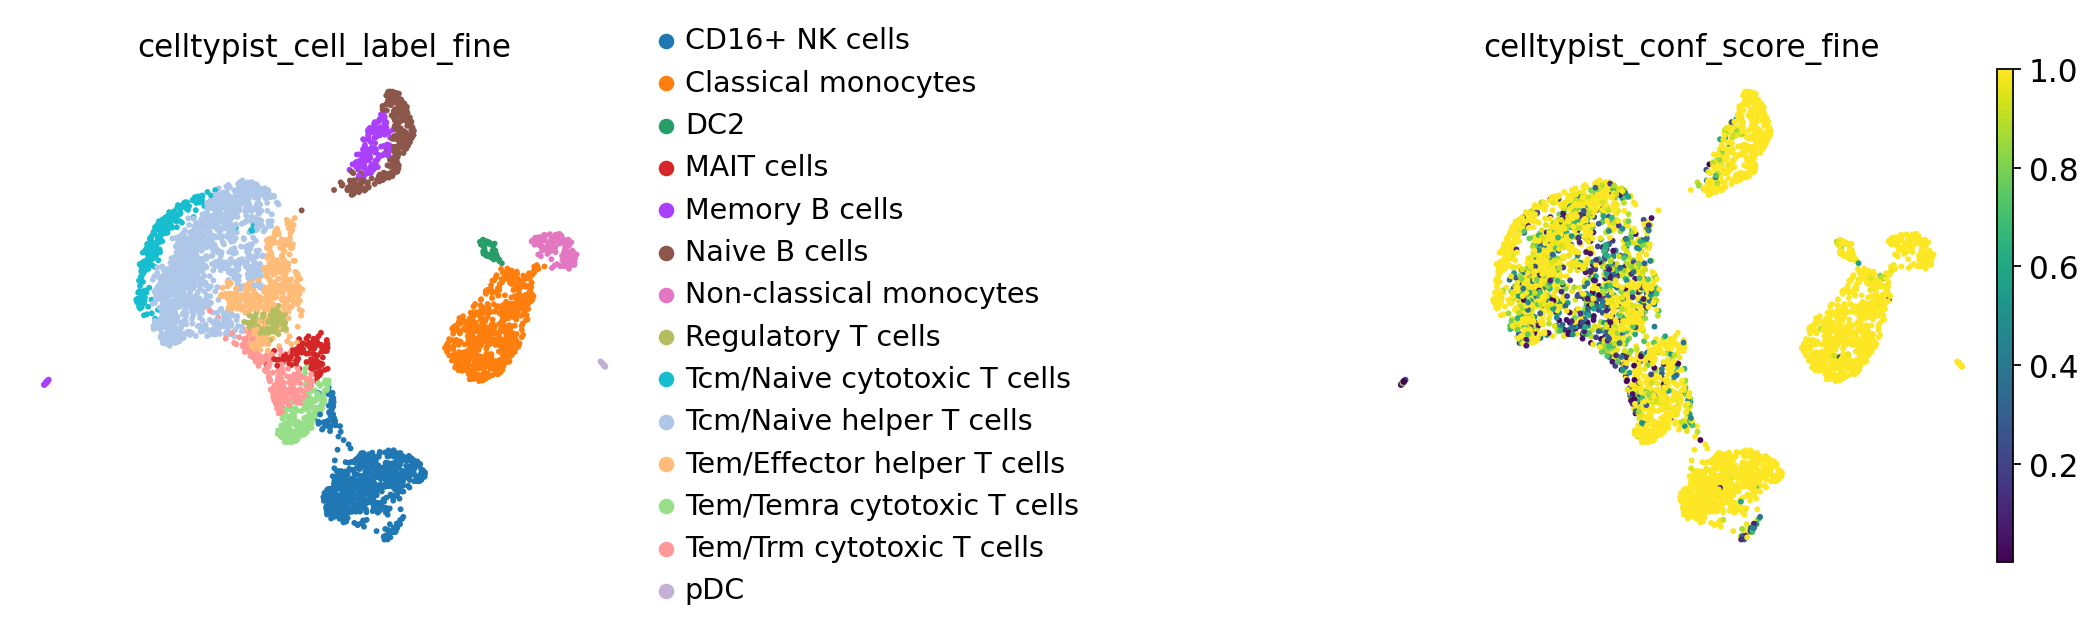

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /home/MazutisLab/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 10578 cells and 4504 genes
🔗 Matching reference genes in the model
🧬 1771 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'feature_types' as categorical


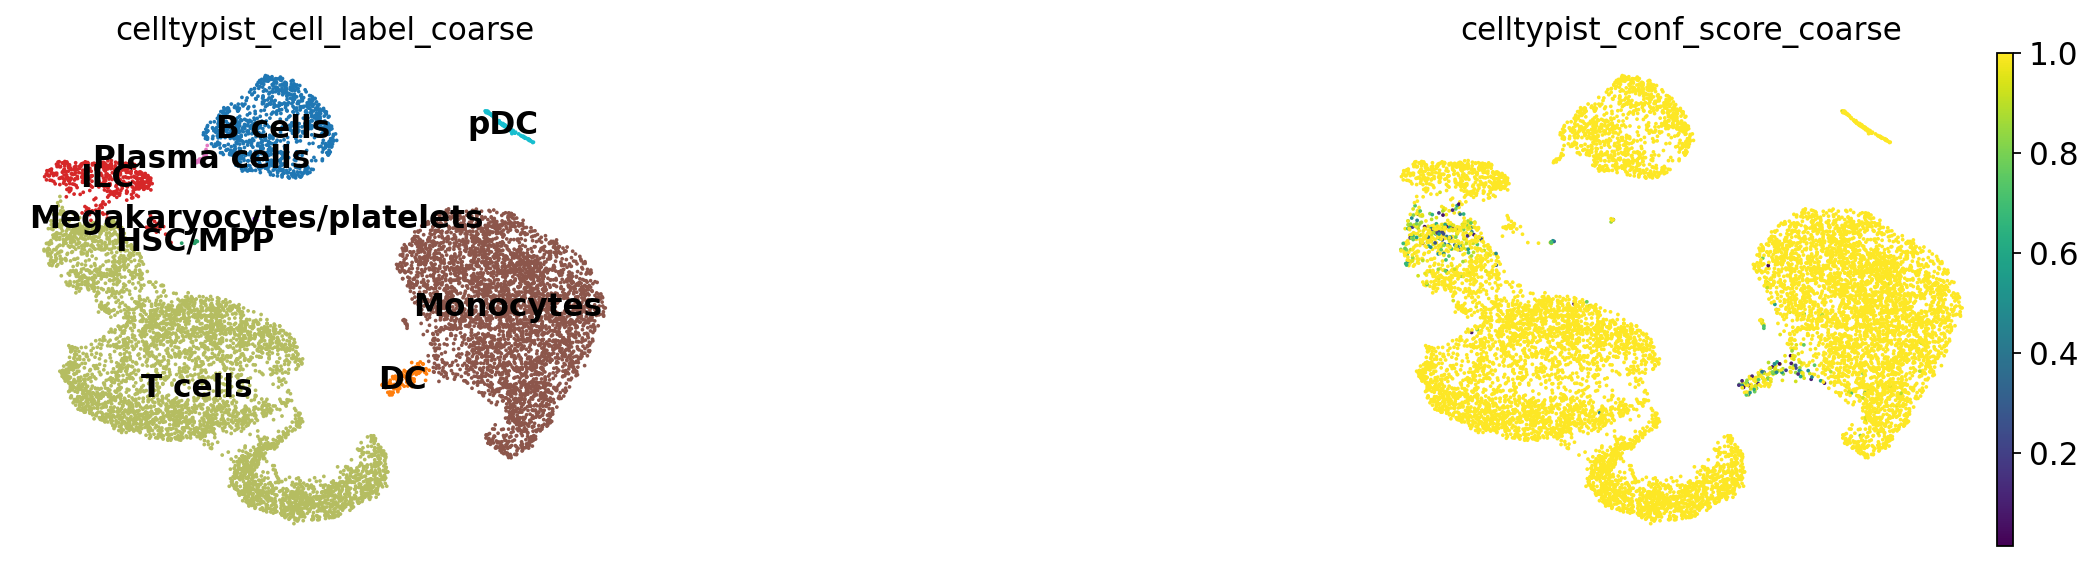

🔬 Input data has 10578 cells and 4504 genes
🔗 Matching reference genes in the model
🧬 1771 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


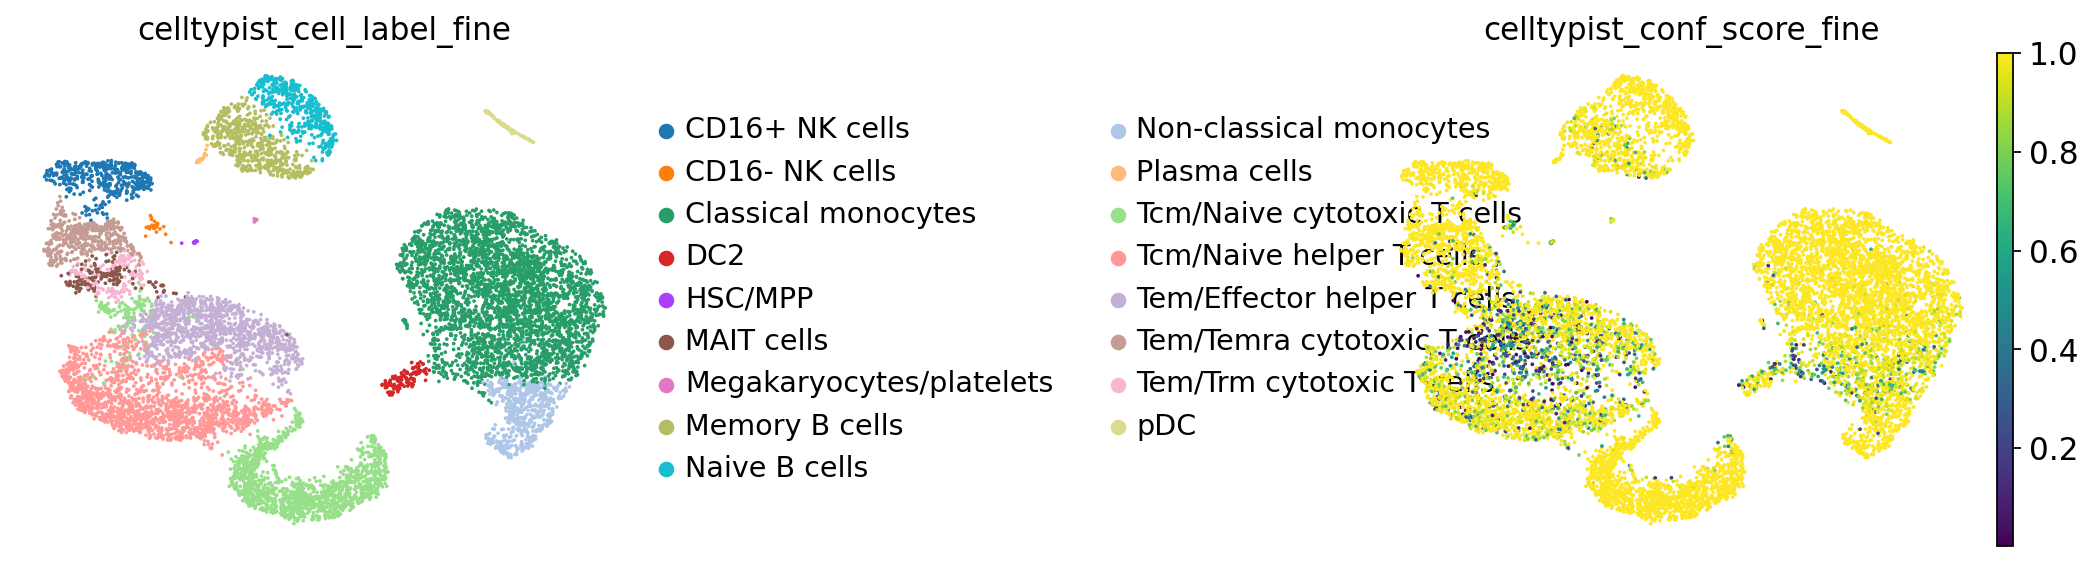

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /home/MazutisLab/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 10102 cells and 4443 genes
🔗 Matching reference genes in the model
🧬 1743 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'feature_types' as categorical


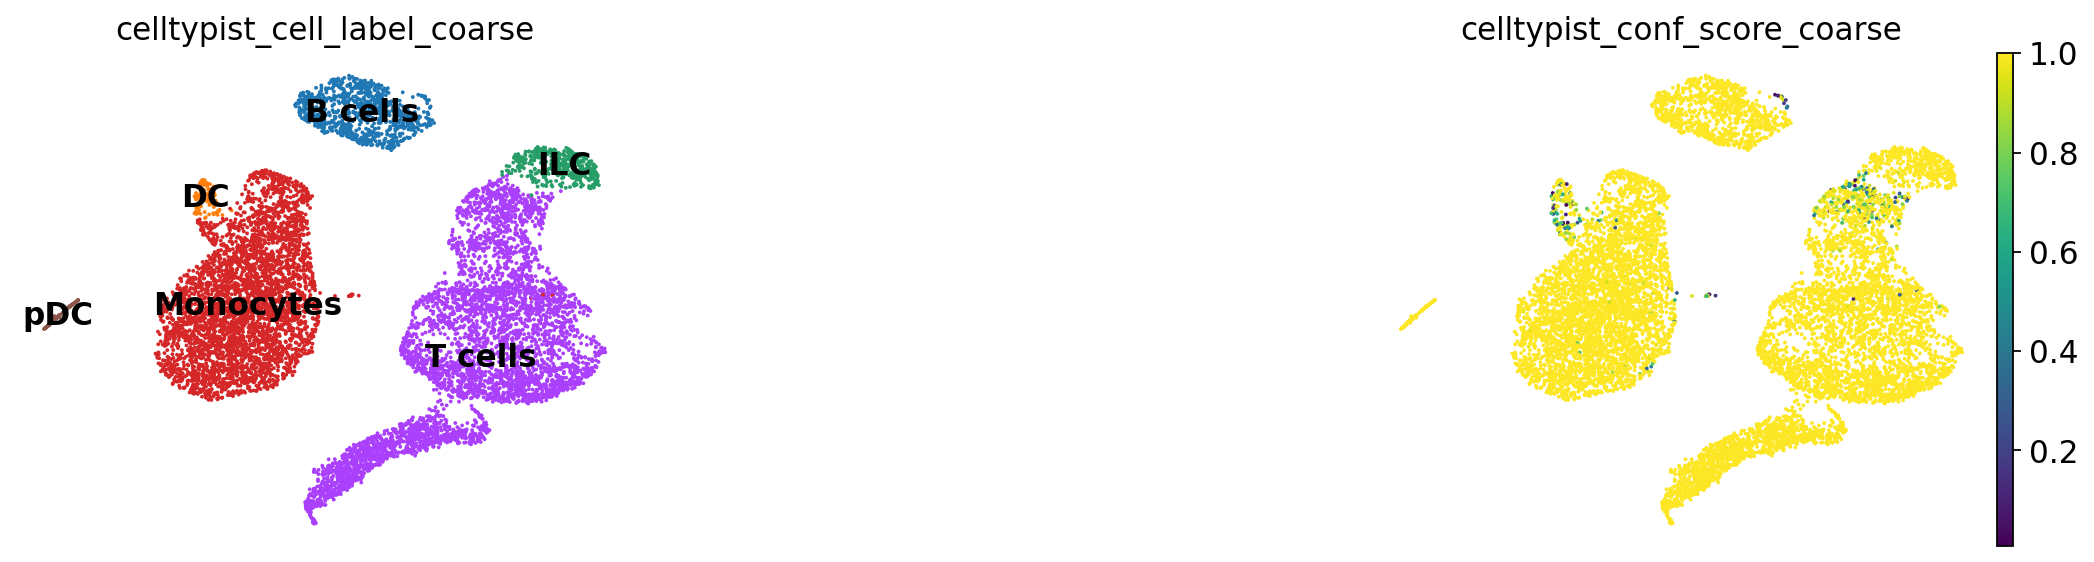

🔬 Input data has 10102 cells and 4443 genes
🔗 Matching reference genes in the model
🧬 1743 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


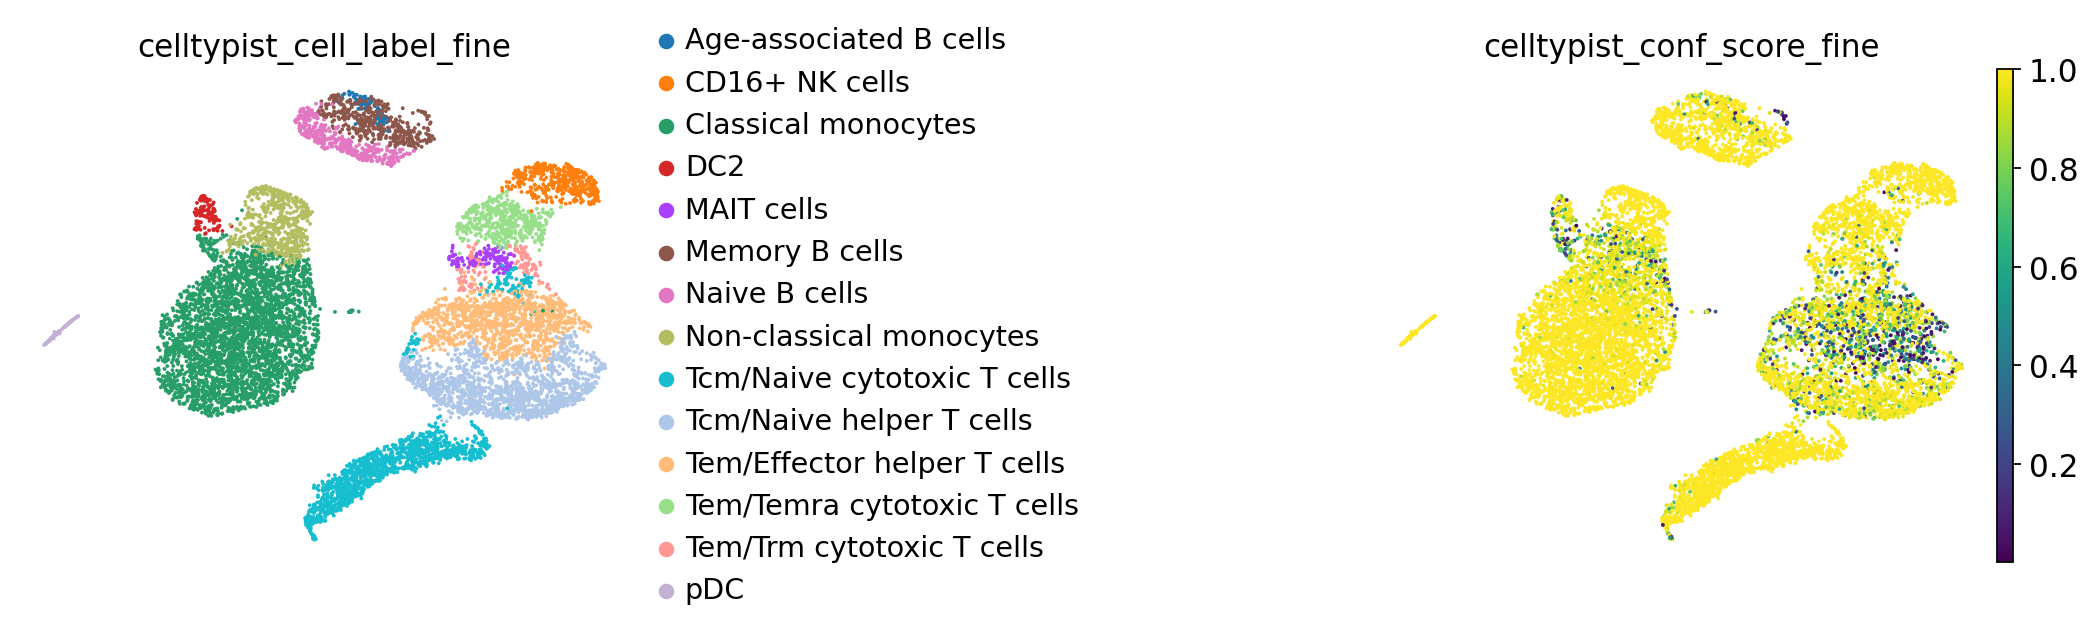

In [14]:
for sample in samples:
    if sample.startswith("PBMC_10x"):
        CellTypist(adatas[sample])
        adatas[sample].obs["cell_type"] = adatas[sample].obs["celltypist_cell_label_coarse"]

In [15]:
for sample in samples:
    if sample.startswith("brain"):
        sc.tl.leiden(adatas[sample], resolution=0.1, key_added="cell_type")

In [16]:
for sample in samples:
    if sample.startswith("PBMC_indrops"):
        sc.tl.leiden(adatas[sample], resolution=0.1, key_added="cell_type")

In [17]:
for sample in samples:
    if sample.startswith("eye"):
        sc.tl.leiden(adatas[sample], resolution=0.1, key_added="cell_type")

In [18]:
for sample in samples:
    if sample == "lung_2":
        sc.tl.leiden(adatas[sample], resolution=0.1, key_added="cell_type")
    if sample == "lung_5":
        sc.tl.leiden(adatas[sample], resolution=0.25, key_added="cell_type")
    if sample == "lung_7":
        sc.tl.leiden(adatas[sample], resolution=0.3, key_added="cell_type")
    if sample == "lung_8":
        sc.tl.leiden(adatas[sample], resolution=0.25, key_added="cell_type")

In [19]:
res = { "PBMC_indrops" : 0.1, "PBMC_indrops_2" : 0.1,
        "brain" : 0.1, "brain_2" : 0.1,
        "eye" : 0.1, "eye_2" : 0.1, "eye_3" : 0.1,
        "lung_2" : 0.1, "lung_5" : 0.25, "lung_7" : 0.3, "lung_8" : 0.25}

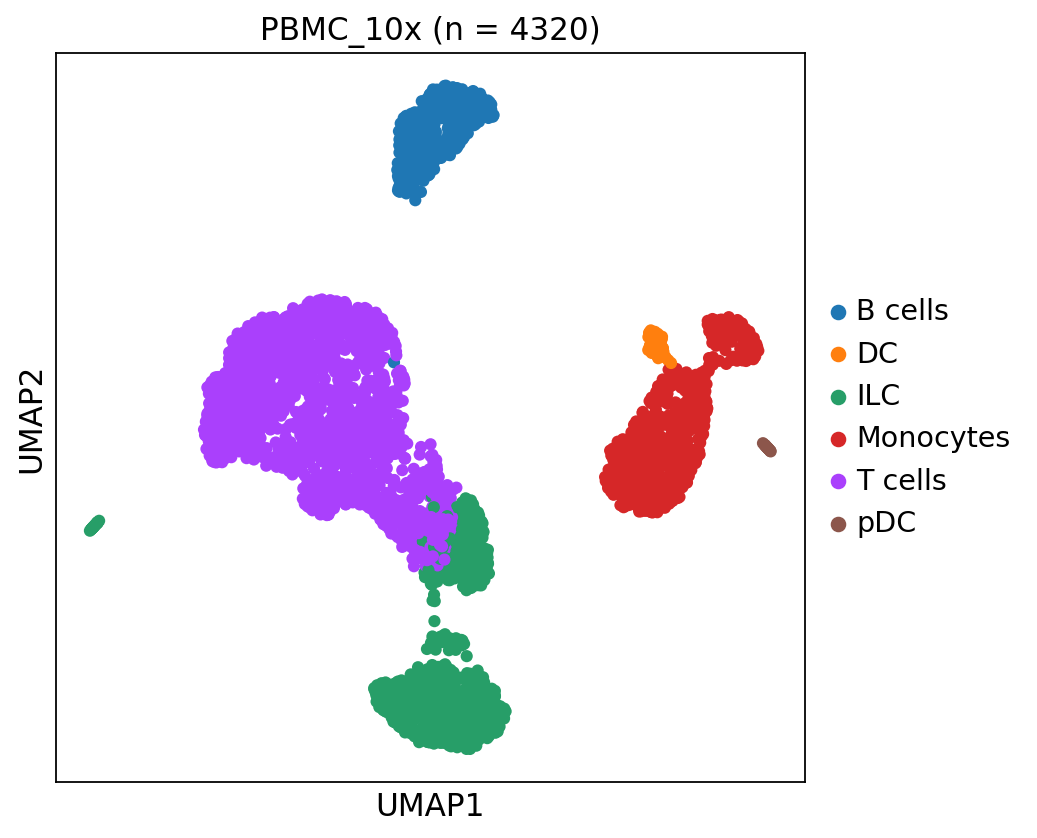

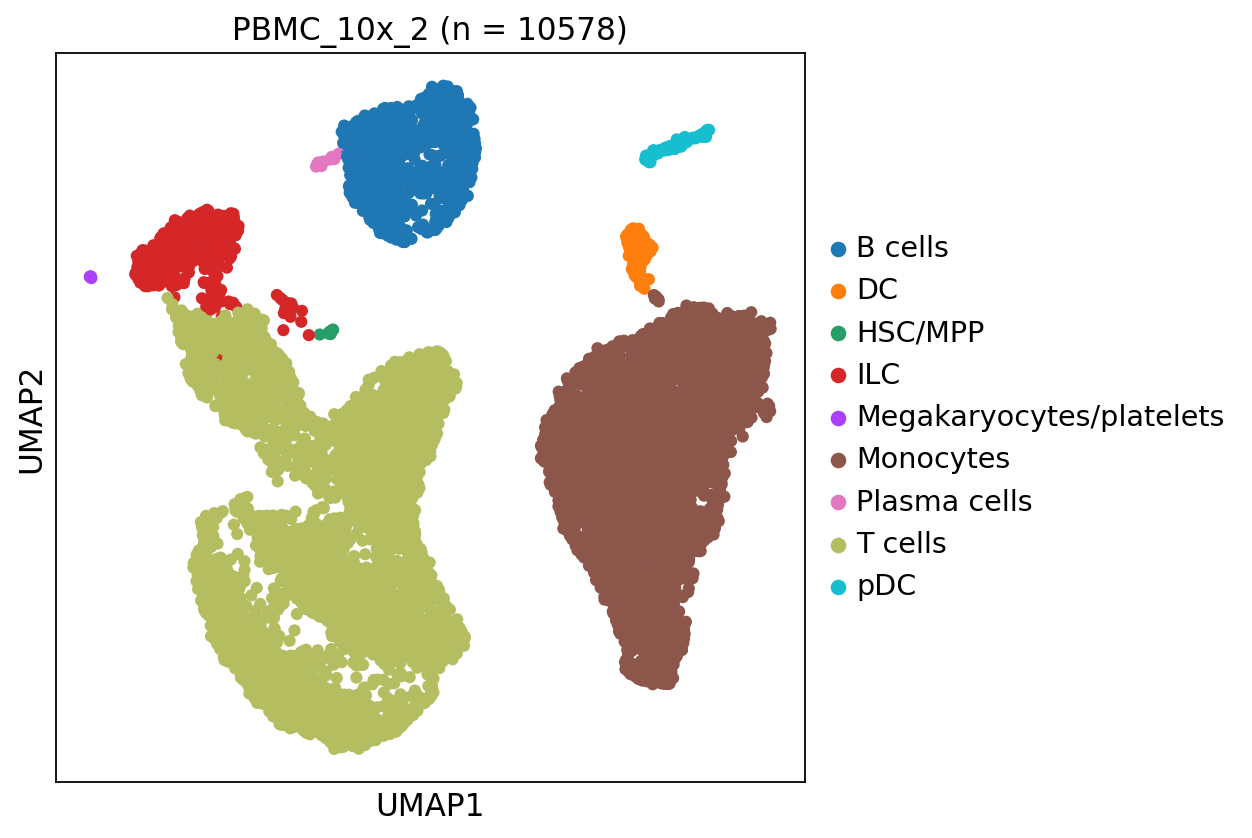

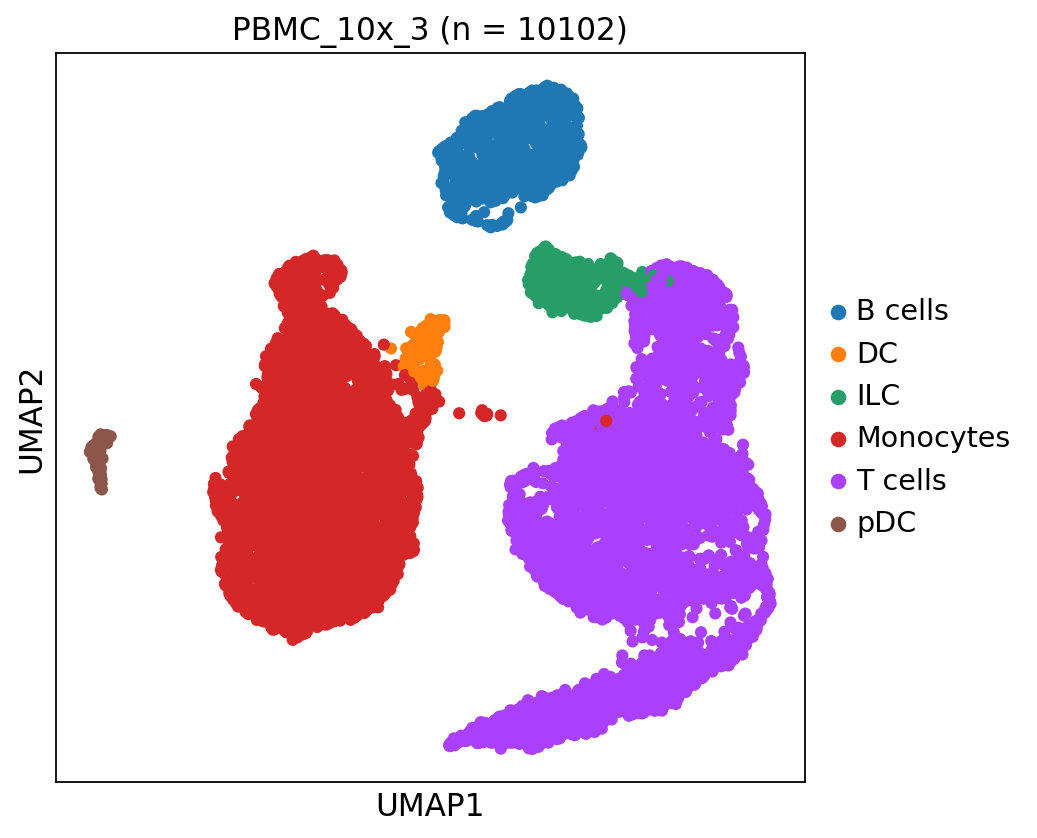

... storing 'feature_types' as categorical


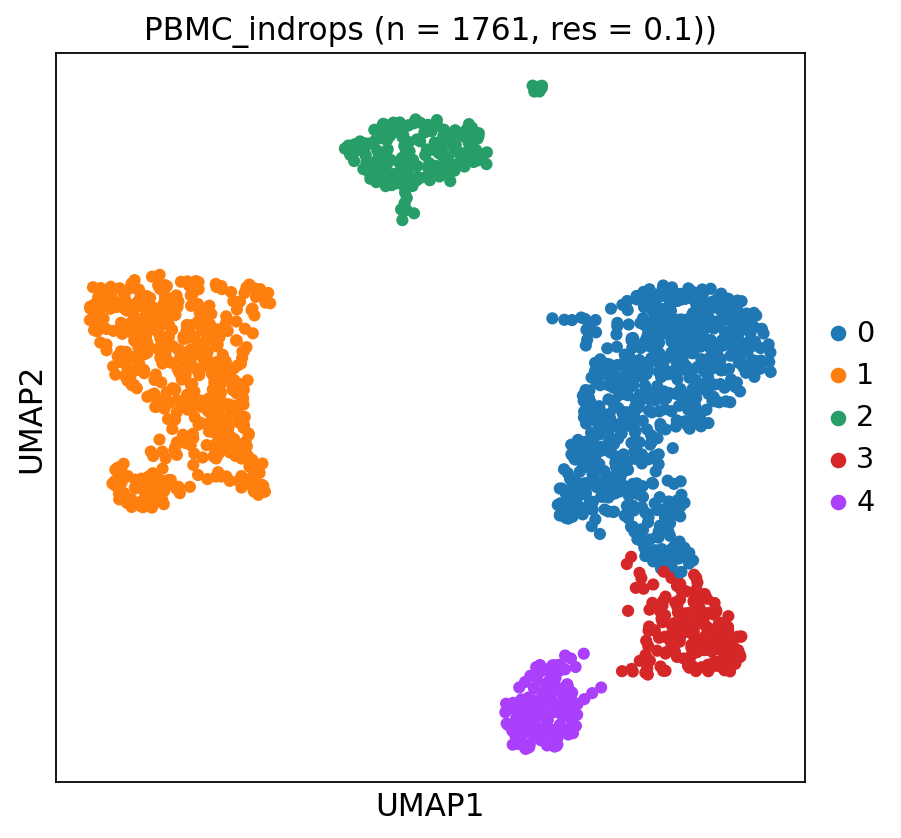

... storing 'feature_types' as categorical


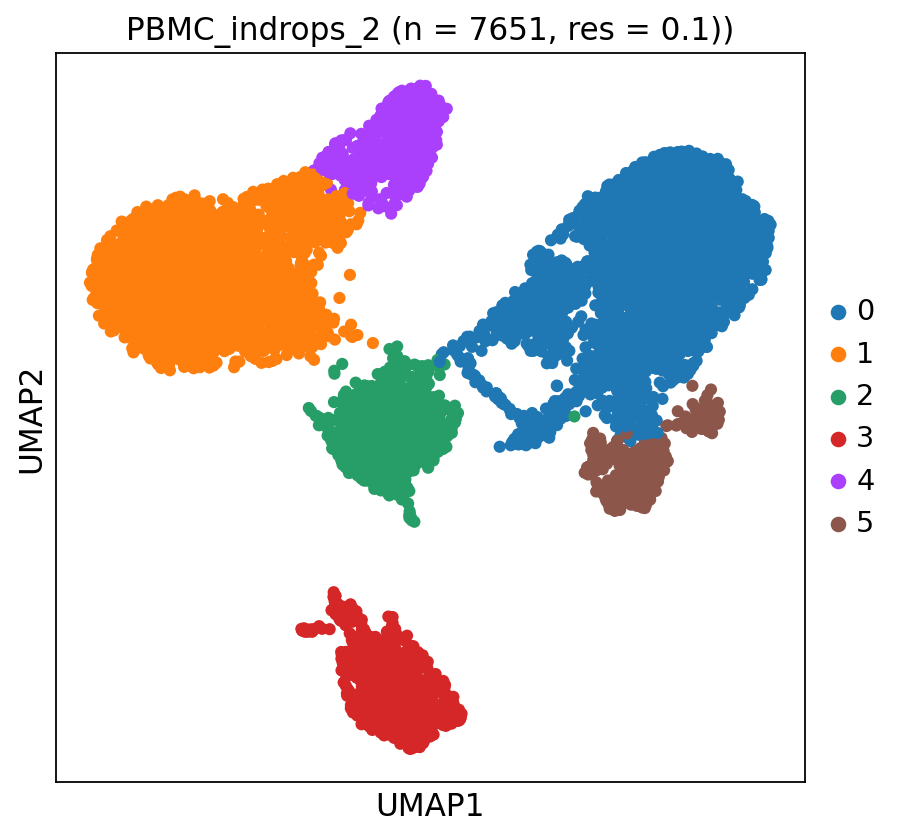

... storing 'feature_types' as categorical


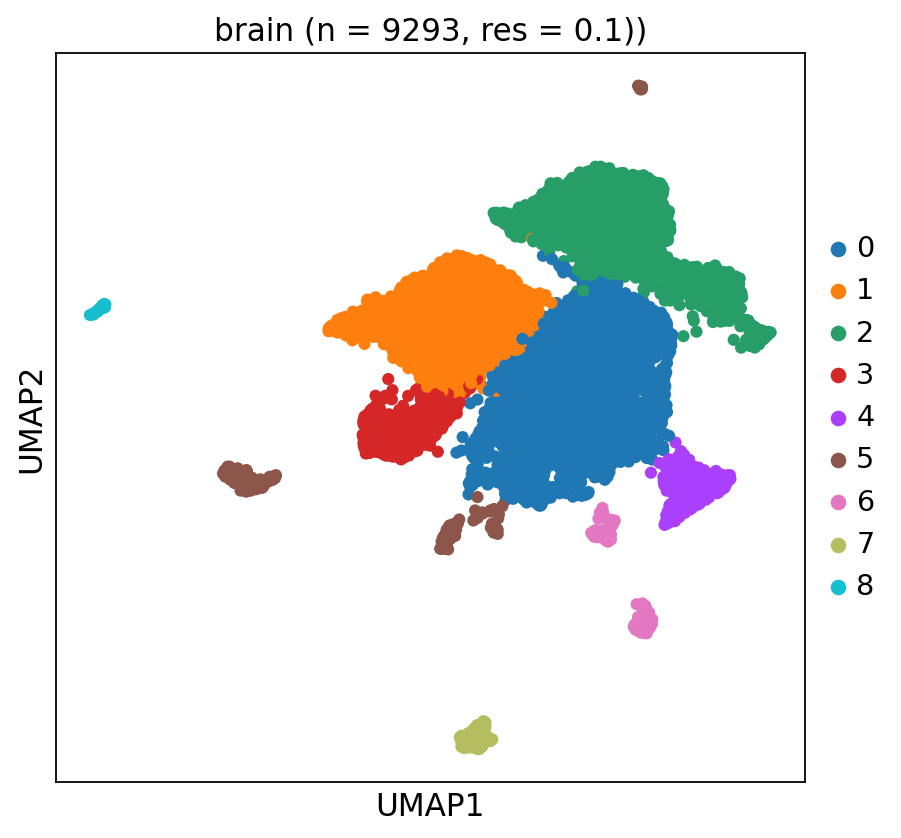

... storing 'feature_types' as categorical


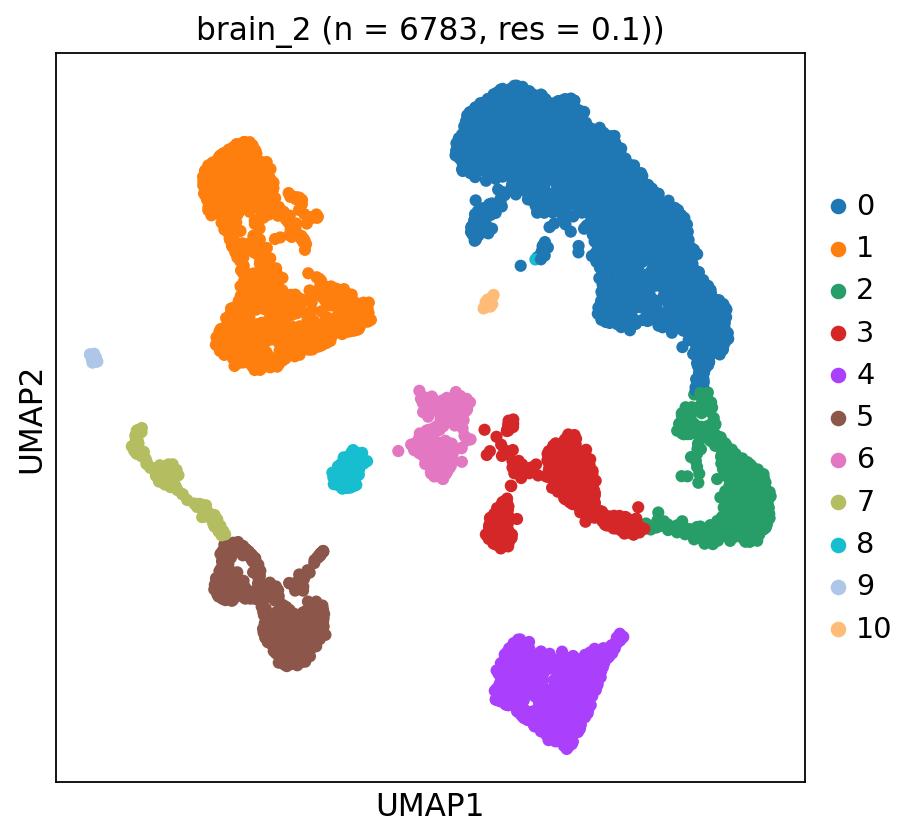

... storing 'feature_types' as categorical


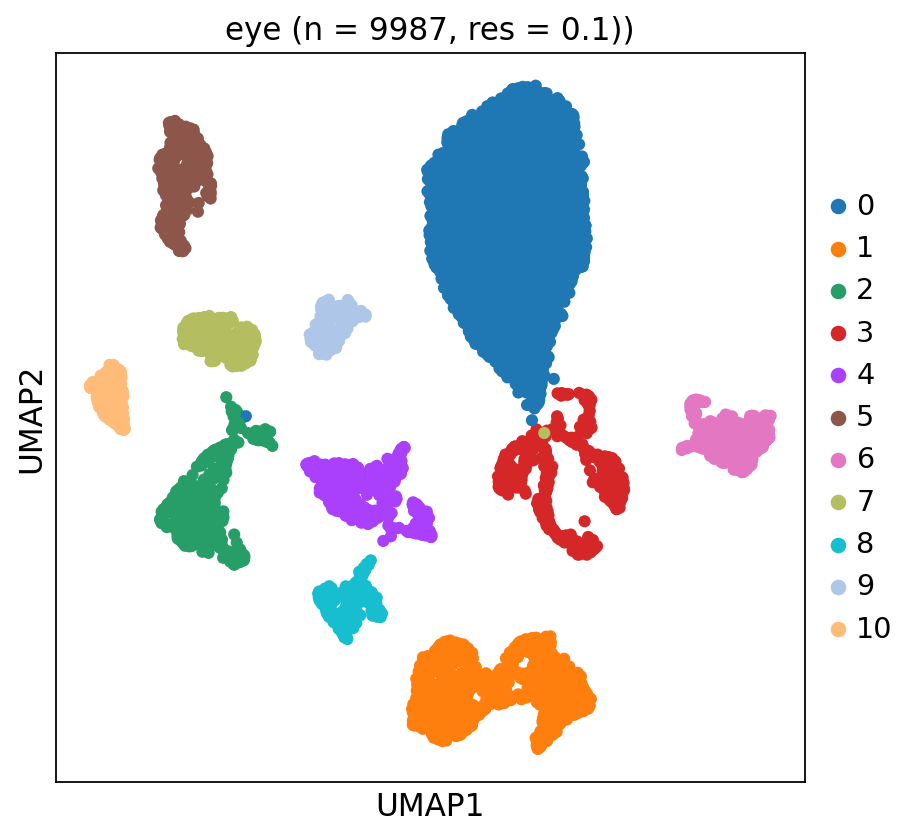

... storing 'feature_types' as categorical


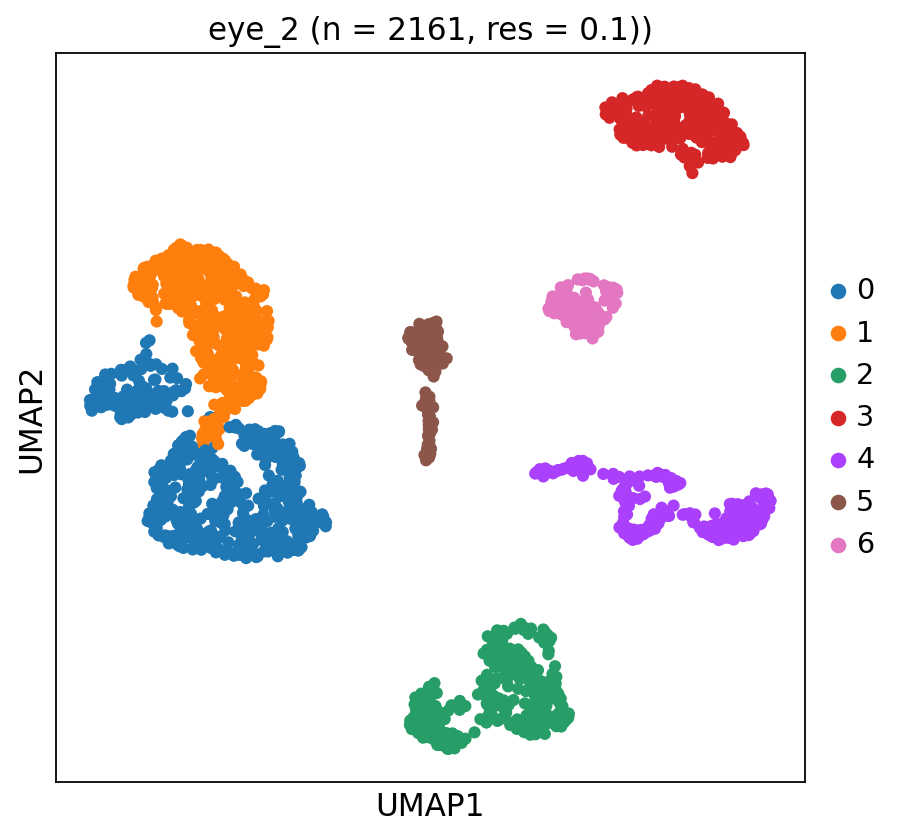

... storing 'feature_types' as categorical


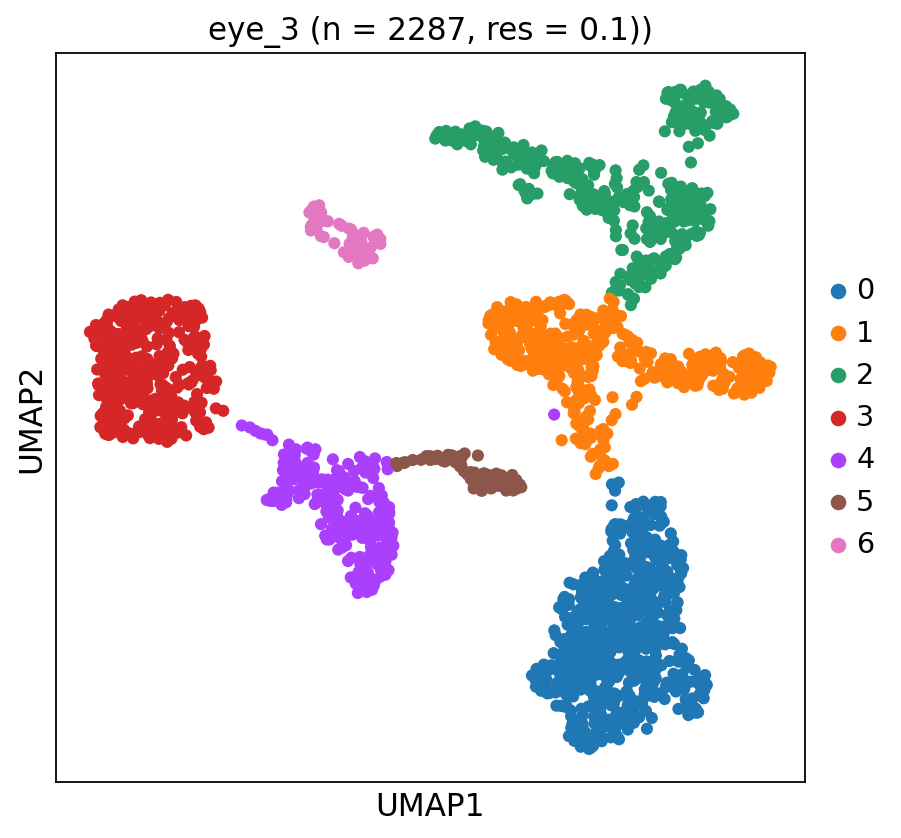

... storing 'feature_types' as categorical


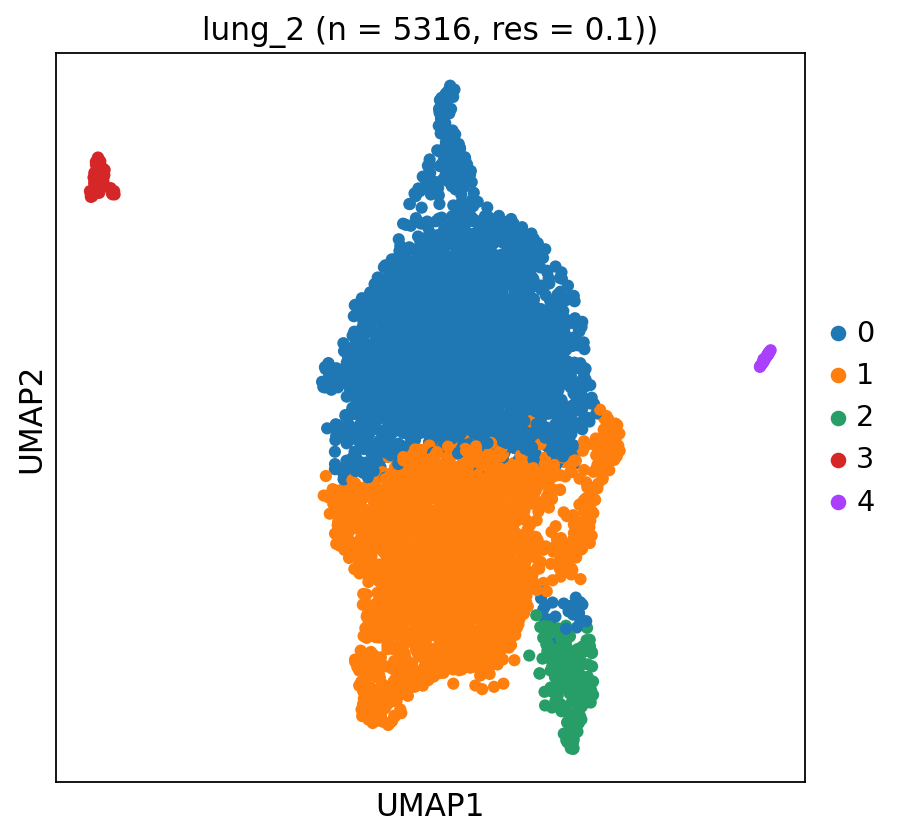

... storing 'feature_types' as categorical


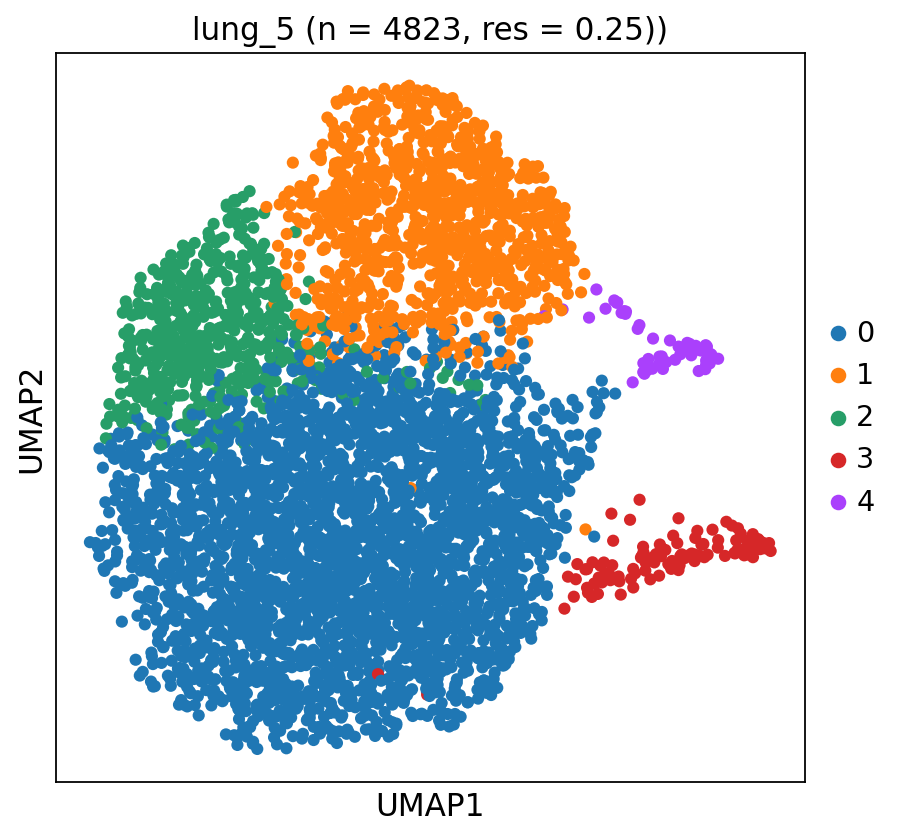

... storing 'feature_types' as categorical


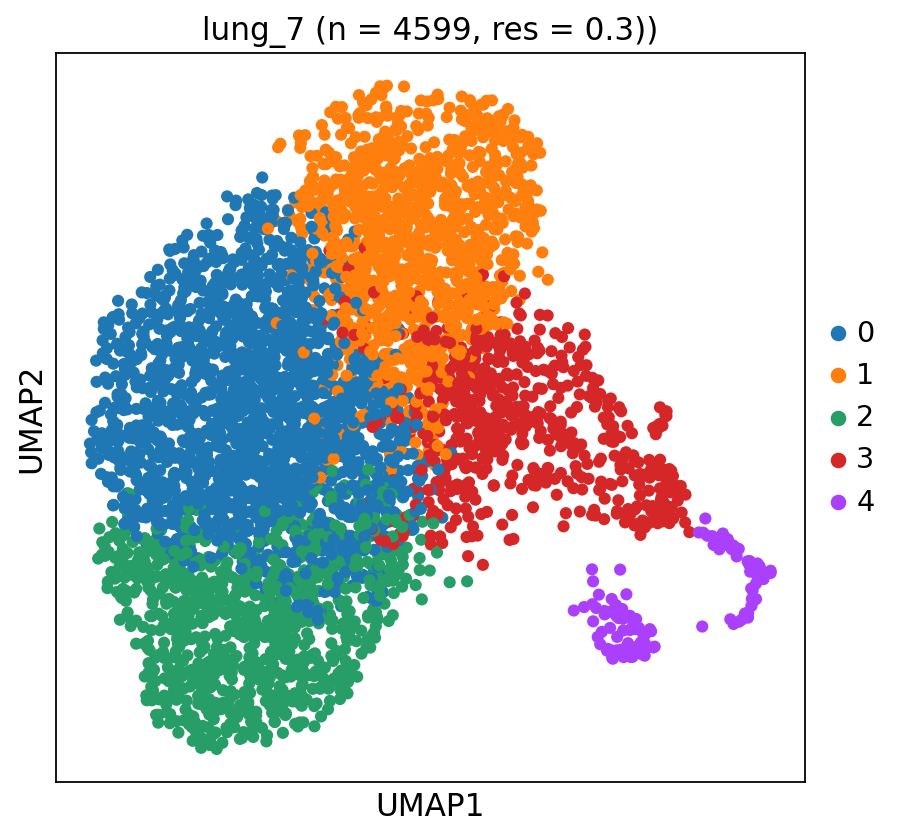

... storing 'feature_types' as categorical


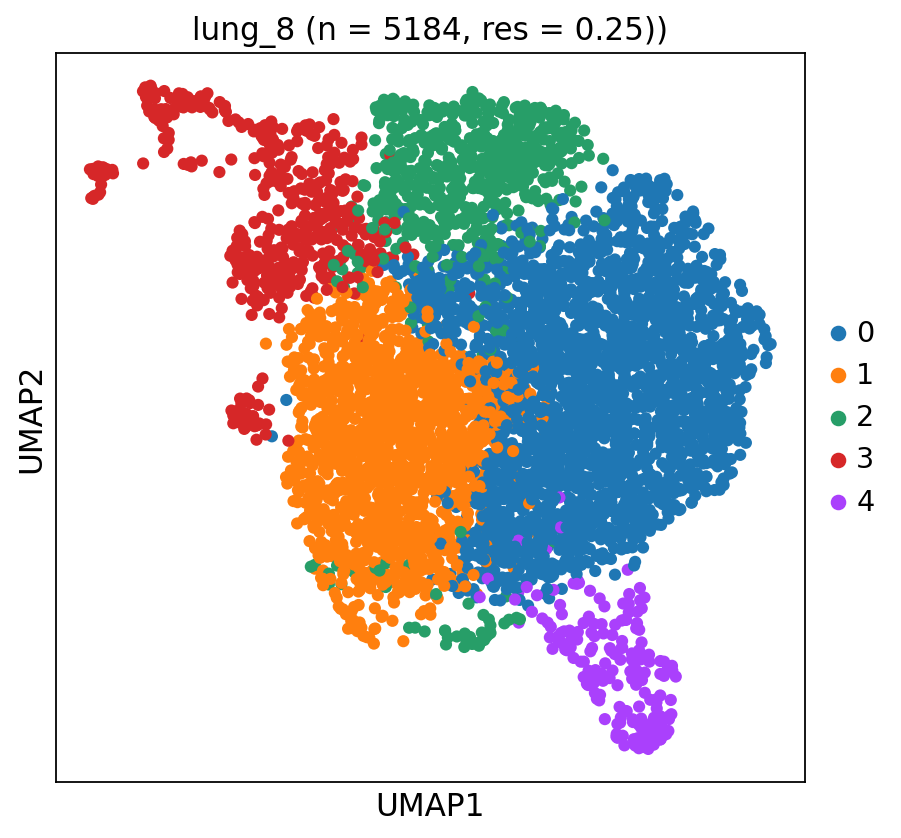

In [23]:
import os
directory = f"../../images/clusterings/"
os.makedirs(directory, exist_ok=True)
for sample in samples:
    fig, ax = plt.subplots(figsize=(6, 6))
    if sample.startswith("PBMC_10x"):
        title = f"{sample} (n = {adatas[sample].n_obs})"
    else:
        title = f"{sample} (n = {adatas[sample].n_obs}, res = {res[sample]}))"
    
    sc.pl.umap(adatas[sample], color = "cell_type", show = False,
               title = title, size = 120, ax = ax)

    #plt.savefig(f"{directory}/{sample}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [19]:
for sample in samples:
    sc.tl.rank_genes_groups(adatas[sample], "cell_type", method="wilcoxon")

... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical


In [41]:
dge_df = {}

for sample in samples:
    dge_df[sample] = sc.get.rank_genes_groups_df(adatas[sample], group=None)
    dge_df[sample] = dge_df[sample][dge_df[sample]["names"].str.match(r"^INT\d+$")]
    dge_df[sample] = dge_df[sample][(dge_df[sample]["pvals_adj"] < 0.01) & (dge_df[sample]["logfoldchanges"].abs() > 0.5)]
    dge_df[sample]["group"] = f"{sample}_" + dge_df[sample]["group"].astype(str)

In [42]:
for sample in samples:
    pca_loadings = adatas[sample].varm["PCs"][:, :10]
    pc_weights = adatas[sample].uns["pca"]["variance_ratio"][:10]
    gene_names = adatas[sample].var_names.to_list()

    loadings_df = pd.DataFrame(pca_loadings, index=gene_names, columns=[f"PC{i+1}" for i in range(10)])

    # Compute weighted aggregate loading score (sum of squared loadings weighted by variance explained)
    loadings_df["loading_score"] = (loadings_df**2 * pc_weights).sum(axis=1)

    # Merge with existing dataframe based on gene names
    dge_df[sample] = dge_df[sample].merge(loadings_df[["loading_score"]], left_on="names", right_index=True, how="left")

    threshold = dge_df[sample]["loading_score"].quantile(0.98)
    dge_df[sample]["top_2_percent"] = dge_df[sample]["loading_score"] > threshold

In [45]:
for sample in samples:
    dge_df[sample].to_csv(f"../../data/downstream/manualwork/dge/{sample}_dge.tsv", index = False, sep="\t")

In [46]:
combined_df = pd.concat(dge_df.values(), ignore_index=True)
print(len(combined_df))

3692


In [48]:
combined_df = combined_df.loc[combined_df.assign(abs_score=combined_df["scores"].abs())
                              .groupby("names")["abs_score"].idxmax()]

In [50]:
combined_df.to_csv("../../data/downstream/manualwork/dge.tsv", index = False, sep="\t")

In [51]:
dge = list(set(combined_df['names'].to_list()))

In [52]:
with open("../../data/downstream/manualwork/dge.list", "w") as output:
    for gene in dge:
        output.write(f"{gene}\n")